<a href="https://colab.research.google.com/github/ghosthye/calculo-numerico-computacional-2026/blob/main/Aula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

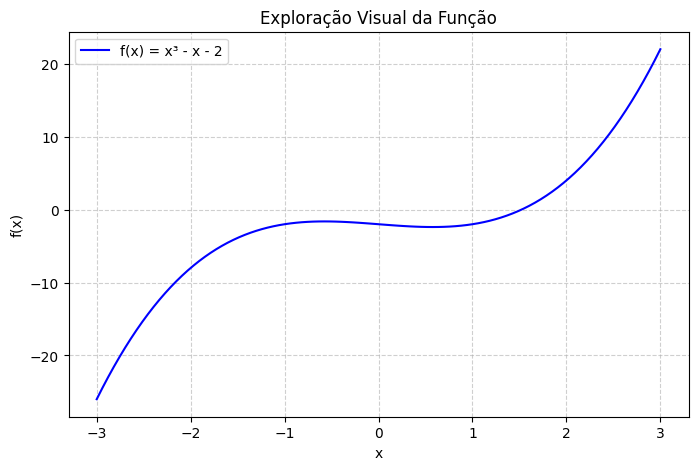

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x**3 - x - 2

x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)


plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='f(x) = x³ - x - 2', color='blue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Exploração Visual da Função')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

# Questão 1: Quantas raízes aparentes existem?
Visualmente, a função cruza o eixo horizontal apenas 1 vez neste intervalo. Portanto, há 1 raiz real aparente.
# Em que região aproximada elas estão?
A linha cruza o eixo X no trecho positivo, especificamente entre os valores de $x = 1$ e $x = 2$ (aparentemente bem no meio desse intervalo).

In [3]:
x_inteiros = np.arange(-3, 4)
y_inteiros = f(x_inteiros)

print("Tabela de Valores:")
for x, y in zip(x_inteiros, y_inteiros):
    print(f"f({x}) = {y}")

Tabela de Valores:
f(-3) = -26
f(-2) = -8
f(-1) = -2
f(0) = -2
f(1) = -2
f(2) = 4
f(3) = 22


# Questão 2: Em qual intervalo ocorre mudança de sinal?
Ocorre uma mudança de sinal entre $x = 1$ (onde $f(1) = -2$) e $x = 2$ (onde $f(2) = 4$).
# Existe mais de um intervalo válido?
No intervalo analisado de $[-3, 3]$, não. Há apenas essa única troca de negativo para positivo.
# Qual intervalo você escolheria para estudar primeiro?
O intervalo $[1, 2]$, pois é onde a função transita de um valor negativo para um positivo, garantindo a travessia pelo zero.

In [8]:
a = 1.0
b = 2.0

print("--- Refinamento Progressivo (Intuição da Bisseção) ---")
for i in range(5):
    ponto_medio = (a + b) / 2

    print(f"Iteração {i+1} | Intervalo: [{a:.4f}, {b:.4f}] | Ponto médio: {ponto_medio:.4f}")


    if f(a) * f(ponto_medio) < 0:
        b = ponto_medio
    else:
        a = ponto_medio

--- Refinamento Progressivo (Intuição da Bisseção) ---
Iteração 1 | Intervalo: [1.0000, 2.0000] | Ponto médio: 1.5000
Iteração 2 | Intervalo: [1.5000, 2.0000] | Ponto médio: 1.7500
Iteração 3 | Intervalo: [1.5000, 1.7500] | Ponto médio: 1.6250
Iteração 4 | Intervalo: [1.5000, 1.6250] | Ponto médio: 1.5625
Iteração 5 | Intervalo: [1.5000, 1.5625] | Ponto médio: 1.5312


# Questão 3: O intervalo pode ser reduzido?
 Sim. Testando o ponto médio e verificando onde o sinal muda, podemos descartar metade do intervalo a cada iteração, tornando a busca cada vez mais estreita e precisa.
# A raiz parece estar mais próxima de qual extremo?
Após a primeira divisão, vemos que $f(1.5) = -0.125$ e $f(2) = 4$. Como o valor em 1.5 está muito mais próximo de zero, sabemos que a raiz está bem colada no 1.5 (e no intervalo inicial [1, 2], ela fica levemente mais próxima do 2 do que do 1).
# Que tipo de método estamos construindo intuitivamente?
O Método da Bisseção. Começamos com um intervalo garantido pela mudança de sinal e o dividimos ao meio repetidamente, escolhendo sempre o subintervalo que contém a inversão de sinal.

# Parte 4 — Análise Conceitual
# Por que a mudança de sinal indica existência de raiz?
Porque, se a função é contínua, quando ela passa de um valor negativo para positivo (ou vice-versa), ela necessariamente precisa cruzar o eixo x em algum ponto. Isso é garantido matematicamente pelo Teorema do Valor Intermediário (ou Teorema de Bolzano).
# A ausência de mudança de sinal garante ausência de raiz?
Não necessariamente. Existe a possibilidade de a função apenas "tocar" o eixo x e voltar, sem trocar de sinal (o que chamamos de raiz de multiplicidade par). O próprio exemplo da Parte 5, $g(x) = (x - 1)^2$, mostra isso: ela tem raiz, mas é positiva de ambos os lados.
# Por que é importante localizar antes de aplicar um método iterativo?
Porque métodos iterativos precisam de um bom ponto inicial ou de um intervalo adequado para funcionarem. Se escolhermos às cegas, o método pode não convergir (ficar calculando para sempre sem achar o resultado), demorar muito, ou encontrar uma raiz diferente da que queremos. No método da bisseção, por exemplo, é obrigatório ter certeza de que existe uma mudança de sinal no intervalo inicial.

# Parte 5 — Desafio Extra
# Existe raiz?
Sim. Existe uma raiz em $x = 1$.
# Há mudança de sinal?
Não. Como a função é um quadrado perfeito, seus resultados serão sempre maiores ou iguais a zero. Ela apenas toca o eixo x em $x = 1$, mas não o atravessa. Como todos os valores ao redor da raiz são positivos, não há troca de sinal.
# Um método baseado apenas em sinal funcionaria?
Não. Métodos como o da Bisseção ou Falsa Posição exigem uma mudança de sinal no intervalo inicial para conseguir "encurralar" a raiz. Como não há essa troca, o algoritmo falharia logo no primeiro passo ao tentar validar o intervalo.